# <span style="color:red"> **LSN - Esercitazione 06**
### <span style="color:green"> 10.04.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

### <span style="color:blue">**_Modello di Ising_**

Il modello di Ising rappresenta uno dei sistemi più studiati nella fisica statistica per comprendere i fenomeni magnetici. Esso descrive un materiale magnetico come un reticolo discreto in cui ogni sito è occupato da uno spin atomico, rappresentato da una variabile binaria: $
s_i = \pm 1 \quad \text{(spin "up" o "down")}$. Questo modello cattura l'essenza dell'interazione tra spin vicini, responsabile del comportamento collettivo come il ferromagnetismo o il paramagnetismo. Nel caso 1D, il modello è risolubile analiticamente. L'Hamiltoniana per un sistema di N spin con interazione a primi vicini è data da (assumendo unità in modo che $\mu_B=1$ e $k_B=1$):
$$
H = 
-J\sum_{i=1}^N s_i s_{i+1}
-\frac{h}{2}\sum_{i=1}^N (s_i + s_{i+1}) 
$$
dove $J>0$ (modello ferromagnetico), e con l'assuzione $s_{N+1} = s_{1}$.

La funzione di partizione per gli $N$ spin, $Z$, può essere calcolata esattamente, e risulta:

$$
Z=\sum_{\{ s_i \}} \exp \left( -\beta H\right) = \lambda_1^N + \lambda_2^N
$$

dove
$\lambda_{1,2} = 
e^{\beta J} 
\cosh (\beta h) \pm \left[ e^{2\beta J} \cosh^2 (\beta h) - 2\sinh (2\beta J) \right]^{1/2}$, 
e $\beta=\frac{1}{k_b T} = \frac{1}{T}$.

Tutte le quantità termodinamiche di interesse possono dunque essere determinate di conseguenza.

## <span style="color:blue">**Esercizio 06.1**

Il modello di Ising può anche essere simulato. Per fare ciò, è necessario avere un algoritmo per campionare il peso di Boltzmann $p(\{ s_i \}) = \exp(-\beta H)/Z$. In questa esercitazione, si sono applicati i due seguenti algoritmi:
- **Algoritmo di Metropolis**: modifica lo stato del sistema cambiando l'orientazione di uno spin scelto casualmente. La mossa è accettata con la seguente probabilità: $$p(s \to s')= \min(1, e^{-\beta \Delta E})$$ dove $\Delta E$ è la variazione di energia del sistema: si osservi che una diminuzione di energia viene sempre accettata.
- **Algoritmo di Gibbs**: a differenza del metodo di Metropolis, in cui le mosse proposte possono essere rifiutate, nell'algoritmo di Gibbs ogni mossa viene sempre accettata. Questo è possibile perché il campionamento avviene direttamente dalla distribuzione condizionale dello stato corrente, dati tutti gli altri stati. La probabilità di transizione nell'algoritmo di Gibbs assume la forma: $$ p(s_i = +1 \, | \, \{s_j\}_{j \neq i}) = \frac{1}{1 + \exp\left(-2\beta \sum_{j \in \text{vicini}} J_{ij} s_j\right)}$$

Nel modello di Ising, l'intensità delle interazioni tra spin è regolata dalla temperatura. Si manifestano, dunque, comportamenti distinti: a basse temperature, l'energia di scambio domina, favorendo l'allineamento degli spin e producendo una magnetizzazione spontanea; ad alte temperature, l'energia termica prevale, disordinando il sistema e riducendo la magnetizzazione a valori trascurabili. Nello studio del modello, si sono esaminate le seguenti grandezze:
- energia interna, che descrive l'energia media del sistema a una data temperatura
- calore specifico, che misura la capacità del sistema di assorbire energia termica
- suscettibilità magnetica, che indica la risposta del sistema a un campo magnetico esterno
- magnetizzazione, che quantifica l'allineamento medio degli spin

a temperature diverse, nell'intervallo $[0.5; 2.0]$. Il sistema è composto di $50$ particelle e $J=1$. Le incertezze statistiche sono calcolate tramite data blocking: sono stati utilizzati $20$ blocchi da $20000$ passi. Si è innanzitutto equilibrato il sistema, e si sono fatte poi le simulazioni alle varie temperature, partendo dalla più alta, e via via scendendo: per evitare di ripetere ongi volta l'equilibrazione, per ogni simulazione si è ripartiti dalla configurazione finale della simulazione precedente.

I grafici sottostanti riportano i risultati ottenuti, confrontati con l'andamento esatto, ottenibile tramite risoluzione analitica del modello di Ising monodimensionale:

**1) Energia interna $U(N,T) = \langle H \rangle_{h=0}$**

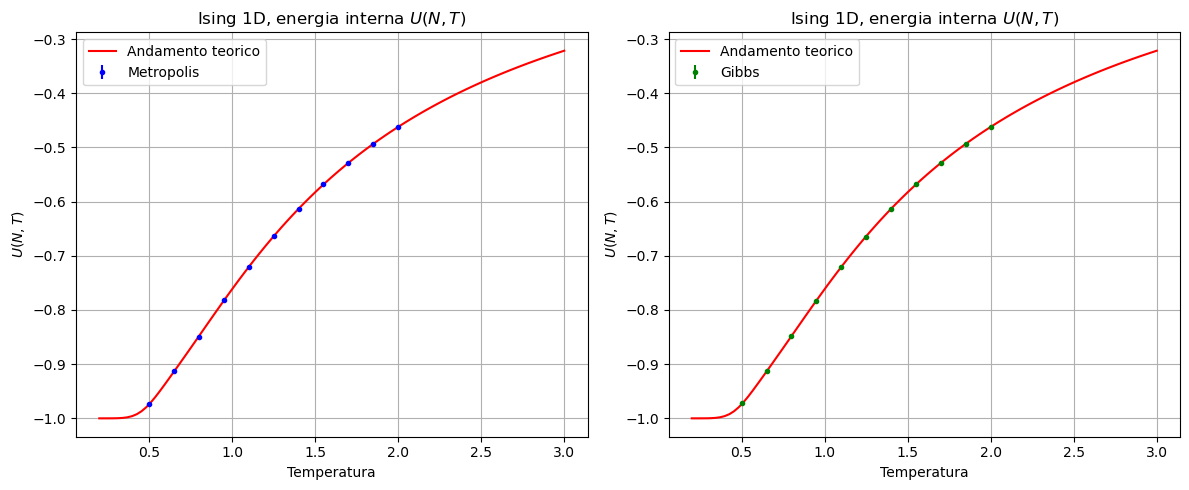

In [15]:
import numpy as np
import matplotlib.pyplot as plt

data_U_m = np.loadtxt("06.1/simulazioni-eseguite/metropolis/total_energy.dat")
data_U_g = np.loadtxt("06.1/simulazioni-eseguite/gibbs/total_energy.dat")

temperature = data_U_m[:,0] # le temperature a cui sono state effettuate le varie simulazioni sono sempre le stesse

U_m = data_U_m[:,3] # carico i valori medi 
error_U_m = data_U_m[:,4]
U_g = data_U_g[:,3] # carico i valori medi 
error_U_g = data_U_g[:,4]

#linea teorica
points=100
T = np.linspace(0.2,3.0,num=points)
beta = 1/T
J = 1.0
Ns = 50
th = np.tanh(J/T)
thN= th**Ns
ch = 1/th
e = -J*( th + ch*thN )/( 1 + thN )

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 riga, 2 colonne

axes[0].errorbar(temperature, U_m, yerr=error_U_m, color = 'b', label='Metropolis', fmt='.')
axes[0].plot(T, e, color = 'r', label='Andamento teorico' )
axes[0].set_xlabel("Temperatura")
axes[0].set_ylabel("$U(N,T)$")
axes[0].set_title("Ising 1D, energia interna $U(N,T)$")
axes[0].grid(True)
axes[0].legend()

axes[1].errorbar(temperature, U_g, yerr=error_U_g, color = 'g', label='Gibbs', fmt='.')
axes[1].plot(T, e, color = 'r', label='Andamento teorico' )
axes[1].set_xlabel("Temperatura")
axes[1].set_ylabel("$U(N,T)$")
axes[1].set_title("Ising 1D, energia interna $U(N,T)$")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()



**2) Capacità termica $ C(N,T) = k_B \beta^2 (\langle H^2 \rangle_{h=0}-\langle H \rangle_{h=0}^2)$**

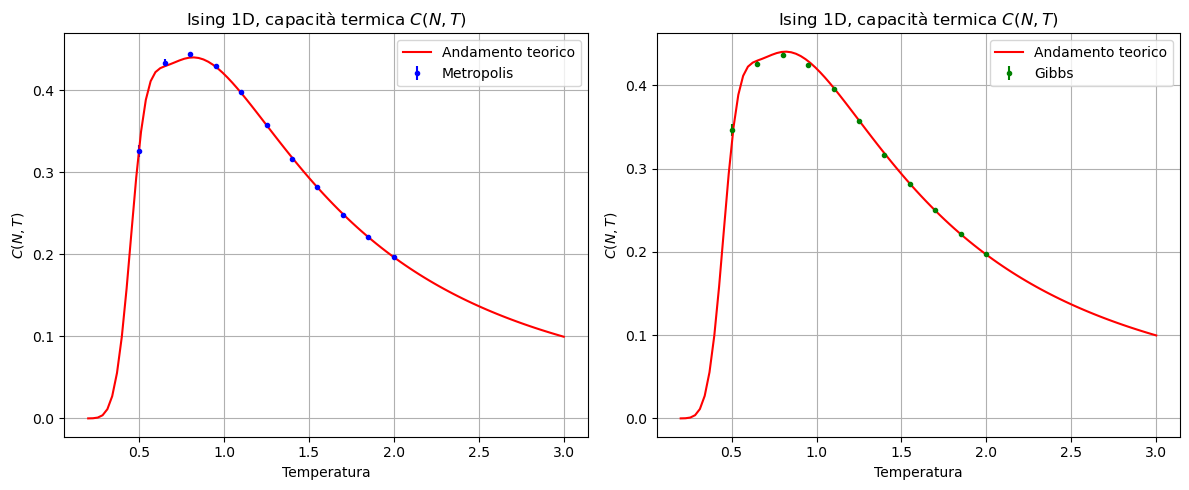

In [11]:
import numpy as np
import matplotlib.pyplot as plt

data_C_m = np.loadtxt("06.1/simulazioni-eseguite/metropolis/specific_heat.dat")
data_C_g = np.loadtxt("06.1/simulazioni-eseguite/gibbs/specific_heat.dat")

temperature = data_C_m[:,0] # le temperature a cui sono state effettuate le varie simulazioni sono sempre le stesse

C_m = data_C_m[:,3] # carico i valori medi 
error_C_m = data_C_m[:,4]
C_g = data_C_g[:,3] # carico i valori medi 
error_C_g = data_C_g[:,4]

#linea teorica
heat=((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 riga, 2 colonne

axes[0].errorbar(temperature, C_m, yerr=error_C_m, color = 'b', label='Metropolis', fmt='.')
axes[0].plot(T, heat, color = 'r', label='Andamento teorico' )
axes[0].set_xlabel("Temperatura")
axes[0].set_ylabel("$C(N,T)$")
axes[0].set_title("Ising 1D, capacità termica $C(N,T)$")
axes[0].grid(True)
axes[0].legend()

axes[1].errorbar(temperature, C_g, yerr=error_C_g, color = 'g', label='Gibbs', fmt='.')
axes[1].plot(T, heat, color = 'r', label='Andamento teorico' )
axes[1].set_xlabel("Temperatura")
axes[1].set_ylabel("$C(N,T)$")
axes[1].set_title("Ising 1D, capacità termica $C(N,T)$")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()



**3) Suscettività $\chi(N,T) = \beta \langle (\sum_{i=1,N}s_i)^2 \rangle_{h=0}$**

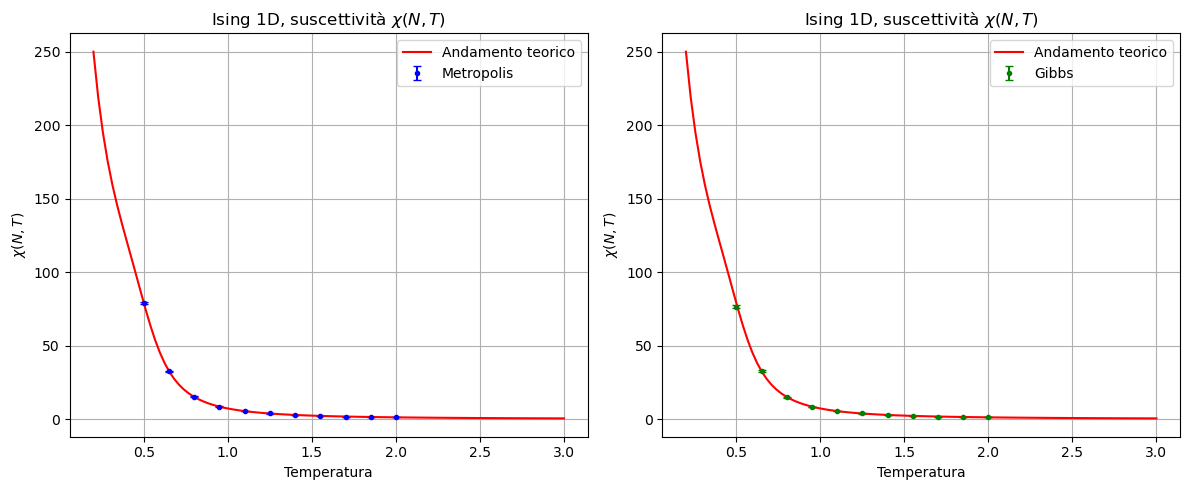

In [13]:
import numpy as np
import matplotlib.pyplot as plt

data_chi_m = np.loadtxt("06.1/simulazioni-eseguite/metropolis/susceptibility.dat")
data_chi_g = np.loadtxt("06.1/simulazioni-eseguite/gibbs/susceptibility.dat")

temperature = data_chi_m[:,0] # le temperature a cui sono state effettuate le varie simulazioni sono sempre le stesse

chi_m = data_chi_m[:,3] # carico i valori medi 
error_chi_m = data_chi_m[:,4]

chi_g = data_chi_g[:,3] # carico i valori medi 
error_chi_g = data_chi_g[:,4]

#linea teorica
points=100
T = np.linspace(0.2,3.0,num=points)
beta = 1/T
J = 1.0
Ns = 50
th = np.tanh(J/T)
thN= th**Ns
X = beta*np.exp(2*beta*J)*(1-thN)/(1+thN)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 riga, 2 colonne

axes[0].errorbar(temperature, chi_m, yerr=error_chi_m, color = 'b', capsize=3 , label='Metropolis',fmt='.')
axes[0].plot(T, X, color = 'r', label='Andamento teorico' )
axes[0].set_xlabel("Temperatura")
axes[0].set_ylabel("$\chi(N,T)$")
axes[0].set_title("Ising 1D, suscettività $\chi(N,T)$")
axes[0].grid(True)
axes[0].legend()

axes[1].errorbar(temperature, chi_g, yerr=error_chi_g, color = 'g', capsize=3 , label='Gibbs', fmt='.')
axes[1].plot(T, X, color = 'r', label='Andamento teorico' )
axes[1].set_xlabel("Temperatura")
axes[1].set_ylabel("$\chi(N,T)$")
axes[1].set_title("Ising 1D, suscettività $\chi(N,T)$")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()




**4) Magnetizzazione $M(N,T,h=0.02)= \langle \sum_{i=1,N}s_i \rangle_{h=0.02}$**

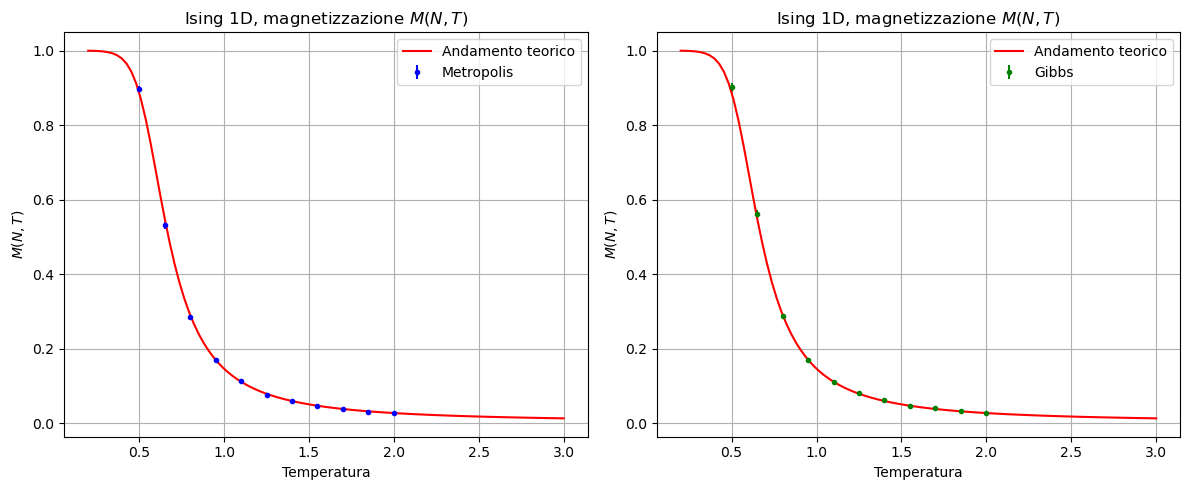

In [14]:
import numpy as np
import matplotlib.pyplot as plt

data_mag_m = np.loadtxt("06.1/simulazioni-eseguite/metropolis/magnetization.dat")
data_mag_g = np.loadtxt("06.1/simulazioni-eseguite/gibbs/magnetization.dat")

temperature = data_mag_m[:,0] # le temperature a cui sono state effettuate le varie simulazioni sono sempre le stesse

mag_m = data_mag_m[:,3] # carico i valori medi 
error_mag_m = data_mag_m[:,4]

mag_g = data_mag_g[:,3] # carico i valori medi 
error_mag_g = data_mag_g[:,4]

#linea teorica
h=0.02 #external field
b = 1/T

l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
Z = l1**Ns + l2**Ns
M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 riga, 2 colonne

axes[0].errorbar(temperature, mag_m, yerr=error_mag_m, color = 'b', label='Metropolis', fmt='.')
axes[0].plot(T, M, color = 'r', label='Andamento teorico' )
axes[0].set_xlabel("Temperatura")
axes[0].set_ylabel("$M(N,T)$")
axes[0].set_title("Ising 1D, magnetizzazione $M(N,T)$")
axes[0].grid(True)
axes[0].legend()

axes[1].errorbar(temperature, mag_g, yerr=error_mag_g, color = 'g', label='Gibbs', fmt='.')
axes[1].plot(T, M, color = 'r', label='Andamento teorico' )
axes[1].set_xlabel("Temperatura")
axes[1].set_ylabel("$M(N,T)$")
axes[1].set_title("Ising 1D, magnetizzazione $M(N,T)$")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


I risultati prodotti riproducono bene l'andamento teorico, ed entrambi gli algoritmi sostanzialmente si equivalgono.

Infine, è interessante osservare l'andamento dell'accettazione in funzione della temperatura. Ovviamente, tale analisi ha senso solo nel caso dell'algoritmo di Metropolis, perché Gibss ha accettanza sempre pari a 1.

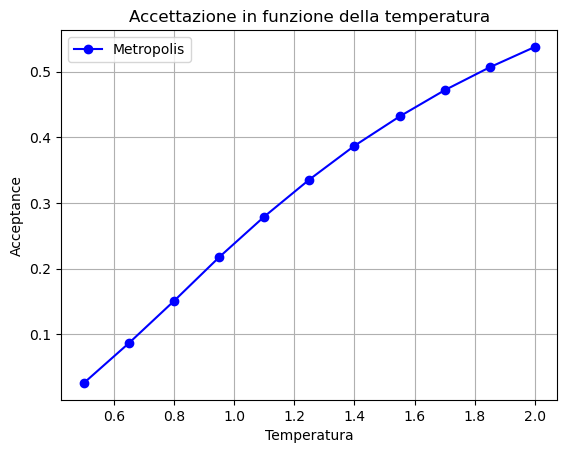

In [3]:
import numpy as np
import matplotlib.pyplot as plt

data_m = np.loadtxt("06.1/simulazioni-eseguite/metropolis/acceptance.dat")
#data_g = np.loadtxt("06.1/simulazioni-eseguite/gibbs/acceptance.dat")

T = data_m[:,0] 
acc_m = data_m[:,1] 
#acc_g = data_g[:,1] 

plt.plot(T, acc_m, 'b-', marker='o', label='Metropolis')
plt.xlabel("Temperatura")
plt.ylabel("Acceptance")
plt.title("Accettazione in funzione della temperatura")
plt.grid(True)
plt.legend()
plt.show()


Si osserva che l'accettazione aumenta con l'aumentare della temperatura: questo si spiega perché, a basse temperature, la maggior parte degli stati del sistema sono "congelati" attorno all'energia minima, pertanto vengono accettate solo poche mosse.